In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/Loan_Default.csv')
display(df.head())

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758.0,CIB,25-34,to_inst,98.728814,south,direct,1.0,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552.0,EXP,55-64,to_inst,NaN,North,direct,1.0,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834.0,CIB,35-44,to_inst,80.019685,south,direct,0.0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587.0,CIB,45-54,not_inst,69.376900,North,direct,0.0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602.0,EXP,25-34,not_inst,91.886544,North,direct,0.0,39.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65843 entries, 0 to 65842
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         65843 non-null  int64  
 1   year                       65843 non-null  int64  
 2   loan_limit                 64369 non-null  object 
 3   Gender                     65843 non-null  object 
 4   approv_in_adv              65476 non-null  object 
 5   loan_type                  65843 non-null  object 
 6   loan_purpose               65789 non-null  object 
 7   Credit_Worthiness          65843 non-null  object 
 8   open_credit                65843 non-null  object 
 9   business_or_commercial     65843 non-null  object 
 10  loan_amount                65842 non-null  float64
 11  rate_of_interest           49776 non-null  float64
 12  Interest_rate_spread       49687 non-null  float64
 13  Upfront_charges            48340 non-null  flo

### Removing Null and Duplicate Rows

In [5]:
print(f"Original DataFrame shape: {df.shape}")

# Drop rows with any null values (just in case, after imputation)
initial_rows = df.shape[0]
df.dropna(inplace=True)
print(f"DataFrame shape after dropping nulls: {df.shape} ({initial_rows - df.shape[0]} rows removed)")

# Drop duplicate rows
duplicate_rows_before = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"DataFrame shape after dropping duplicates: {df.shape} ({duplicate_rows_before - df.duplicated().sum()} duplicate rows removed)")

print("\nFirst 5 rows of the DataFrame after cleaning:")
display(df.head())

Original DataFrame shape: (65843, 34)
DataFrame shape after dropping nulls: (43606, 34) (22237 rows removed)
DataFrame shape after dropping duplicates: (43606, 34) (0 duplicate rows removed)

First 5 rows of the DataFrame after cleaning:


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834.0,CIB,35-44,to_inst,80.019685,south,direct,0.0,46.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602.0,EXP,25-34,not_inst,91.886544,North,direct,0.0,39.0
5,24895,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,EXP,864.0,EXP,35-44,not_inst,70.089286,North,direct,0.0,40.0
6,24896,2019,cf,Joint,pre,type1,p3,l1,nopc,nob/c,...,EXP,860.0,EXP,55-64,to_inst,79.109589,North,direct,0.0,44.0
8,24898,2019,cf,Joint,nopre,type1,p3,l1,nopc,nob/c,...,CIB,580.0,EXP,55-64,to_inst,78.765690,central,direct,0.0,44.0


In [6]:
display(df.describe())

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,43606.000000,43606.0,4.360600e+04,43606.000000,43606.000000,43606.000000,43606.000000,4.360600e+04,43606.000000,43606.000000,43606.000000,43606.0,43606.000000
mean,57749.313420,2019.0,3.344049e+05,4.077806,0.463853,3391.525145,334.291611,5.092267e+05,7187.363207,699.821126,71.129089,0.0,37.448837
std,18987.182244,0.0,1.746708e+05,0.533026,0.484428,3298.359076,59.633063,3.447054e+05,6743.603810,115.860301,18.078487,0.0,9.944360
min,24892.000000,2019.0,2.650000e+04,2.125000,-0.900700,0.000000,96.000000,2.800000e+04,120.000000,500.000000,4.205452,0.0,5.000000
25%,41353.500000,2019.0,2.065000e+05,3.750000,0.102000,797.870000,360.000000,2.880000e+05,4020.000000,599.000000,59.711779,0.0,31.000000
50%,57619.000000,2019.0,3.065000e+05,3.990000,0.397000,2798.000000,360.000000,4.380000e+05,6000.000000,699.000000,73.936170,0.0,38.000000
75%,74212.750000,2019.0,4.465000e+05,4.500000,0.767500,4991.820000,360.000000,6.380000e+05,8700.000000,801.000000,83.948571,0.0,44.000000
max,90731.000000,2019.0,3.006500e+06,8.000000,3.357000,60000.000000,360.000000,6.908000e+06,377220.000000,900.000000,136.538462,0.0,61.000000


In [7]:
cols_to_drop = [
    "ID", "year", "rate_of_interest", "Interest_rate_spread",
    "Upfront_charges", "Secured_by", "submission_of_application",
    "construction_type", "total_units"
]

df = df.drop(columns=cols_to_drop)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43606 entries, 2 to 65841
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   loan_limit                43606 non-null  object 
 1   Gender                    43606 non-null  object 
 2   approv_in_adv             43606 non-null  object 
 3   loan_type                 43606 non-null  object 
 4   loan_purpose              43606 non-null  object 
 5   Credit_Worthiness         43606 non-null  object 
 6   open_credit               43606 non-null  object 
 7   business_or_commercial    43606 non-null  object 
 8   loan_amount               43606 non-null  float64
 9   term                      43606 non-null  float64
 10  Neg_ammortization         43606 non-null  object 
 11  interest_only             43606 non-null  object 
 12  lump_sum_payment          43606 non-null  object 
 13  property_value            43606 non-null  float64
 14  occupancy_t

In [9]:
df.to_csv('cleaned_loan_default.csv', index=False)
print('DataFrame saved to cleaned_loan_default.csv')

DataFrame saved to cleaned_loan_default.csv


In [10]:
cleaned_df = pd.read_csv('cleaned_loan_default.csv')

In [11]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [12]:
def convert_age_to_numeric(age_str):
    if pd.isna(age_str):
        return np.nan
    if isinstance(age_str, (int, float)):
        return age_str
    if 'years' in age_str:
        return float(age_str.replace(' years', ''))
    if '-' in age_str:
        try:
            lower, upper = map(int, age_str.split('-'))
            return (lower + upper) / 2
        except ValueError:
            return np.nan
    if '<25' in age_str:
        return 20  # Midpoint of 0-25
    if '>74' in age_str:
        return 75 # Representative value for ages above 74
    return np.nan

df['age'] = df['age'].apply(convert_age_to_numeric)
median_age = df['age'].median()
df['age'] = df['age'].fillna(median_age)

df.groupby("Status").mean(numeric_only=True)

,loan_amount,term,property_value,income,Credit_Score,age,LTV,dtir1
Status,,,,,,,,
0.0,334404.875476,334.291611,509226.666055,7187.363207,699.821126,50.135314,71.129089,37.448837


In [13]:
# This cell contains outdated model training code.
# The correct and consolidated model training is in cell d7aa08eb.
# Please execute cell d7aa08eb for model training and then cell f8e4d8d8 for evaluation.


### Fixing the single-class error by reloading data and imputing missing values

In [14]:
# Reload the original dataset to reset the DataFrame to its initial state
df = pd.read_csv('/content/Loan_Default.csv')
print(f"DataFrame reloaded. New shape: {df.shape}")

DataFrame reloaded. New shape: (148670, 34)


In [15]:
# --- Handle missing values by imputation ---

# Impute numerical columns with their median
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Imputed numerical column '{col}' with median: {median_val}")

# Impute categorical columns with their mode
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"Imputed categorical column '{col}' with mode: {mode_val}")

print("\nMissing values after imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Verify 'Status' column still has both classes
print("\nStatus column value counts after imputation:")
print(df['Status'].value_counts())

Imputed numerical column 'rate_of_interest' with median: 3.99
Imputed numerical column 'Interest_rate_spread' with median: 0.3904
Imputed numerical column 'Upfront_charges' with median: 2596.45
Imputed numerical column 'term' with median: 360.0
Imputed numerical column 'property_value' with median: 418000.0
Imputed numerical column 'income' with median: 5760.0
Imputed numerical column 'LTV' with median: 75.13586957
Imputed numerical column 'dtir1' with median: 39.0
Imputed categorical column 'loan_limit' with mode: cf
Imputed categorical column 'approv_in_adv' with mode: nopre
Imputed categorical column 'loan_purpose' with mode: p3
Imputed categorical column 'Neg_ammortization' with mode: not_neg
Imputed categorical column 'age' with mode: 45-54
Imputed categorical column 'submission_of_application' with mode: to_inst

Missing values after imputation:
Series([], dtype: int64)

Status column value counts after imputation:
Status
0    112031
1     36639
Name: count, dtype: int64


In [16]:
# --- Drop specified columns ---
cols_to_drop = [
    "ID", "year", "rate_of_interest", "Interest_rate_spread",
    "Upfront_charges", "Secured_by", "submission_of_application",
    "construction_type", "total_units"
]
df = df.drop(columns=cols_to_drop)
print(f"Columns dropped. New shape: {df.shape}")

Columns dropped. New shape: (148670, 25)


In [17]:
# --- Convert 'age' column to numeric and fill NaNs ---
def convert_age_to_numeric(age_str):
    if pd.isna(age_str):
        return np.nan
    if isinstance(age_str, (int, float)):
        return age_str
    if 'years' in age_str:
        return float(age_str.replace(' years', ''))
    if '-' in age_str:
        try:
            lower, upper = map(int, age_str.split('-'))
            return (lower + upper) / 2
        except ValueError:
            return np.nan
    if '<25' in age_str:
        return 20  # Midpoint of 0-25
    if '>74' in age_str:
        return 75 # Representative value for ages above 74
    return np.nan

df['age'] = df['age'].apply(convert_age_to_numeric)
median_age = df['age'].median()
df['age'] = df['age'].fillna(median_age)
print("Age column converted to numeric and NaNs filled.")

Age column converted to numeric and NaNs filled.


In [18]:
# --- Perform one-hot encoding ---
df_encoded = pd.get_dummies(df, drop_first=True)
print(f"DataFrame encoded. New shape: {df_encoded.shape}")

DataFrame encoded. New shape: (148670, 35)


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np # Import numpy for checking inf values

# Consolidate all data preprocessing steps to ensure df is in the correct state
df = pd.read_csv('/content/Loan_Default.csv')

# Impute numerical columns with their median
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

# Impute categorical columns with their mode
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)

# Drop specified columns
cols_to_drop = [
    "ID", "year", "rate_of_interest", "Interest_rate_spread",
    "Upfront_charges", "Secured_by", "submission_of_application",
    "construction_type", "total_units"
]
df = df.drop(columns=cols_to_drop)

# Convert 'age' column to numeric and fill NaNs
def convert_age_to_numeric(age_str):
    if pd.isna(age_str):
        return np.nan
    if isinstance(age_str, (int, float)):
        return age_str
    if 'years' in age_str:
        return float(age_str.replace(' years', ''))
    if '-' in age_str:
        try:
            lower, upper = map(int, age_str.split('-'))
            return (lower + upper) / 2
        except ValueError:
            return np.nan
    if '<25' in age_str:
        return 20  # Midpoint of 0-25
    if '>74' in age_str:
        return 75 # Representative value for ages above 74
    return np.nan

df['age'] = df['age'].apply(convert_age_to_numeric)
median_age = df['age'].median()
df['age'] = df['age'].fillna(median_age)

# Perform one-hot encoding
df_encoded = pd.get_dummies(df, drop_first=True)
print(f"DataFrame encoded. New shape: {df_encoded.shape}")

# Check for non-numeric columns in df_encoded and convert them
non_numeric_cols_df_encoded = df_encoded.select_dtypes(exclude=np.number).columns
if len(non_numeric_cols_df_encoded) > 0:
    print(f"Non-numeric columns found in df_encoded: {list(non_numeric_cols_df_encoded)}")
    for col in non_numeric_cols_df_encoded:
        df_encoded[col] = pd.to_numeric(df_encoded[col], errors='coerce')
    # Fill any NaNs introduced by pd.to_numeric (e.g., if a column was 'non-numeric strings')
    df_encoded = df_encoded.fillna(df_encoded.median(numeric_only=True))
    print(f"NaNs after converting non-numeric and filling: {df_encoded.isnull().sum().sum()}")

X = df_encoded.drop("Status", axis=1)
y = df_encoded["Status"]

# Drop rows where 'y' (Status) is NaN
# This ensures that train_test_split does not encounter NaN in the stratification target
valid_indices = y.dropna().index
X = X.loc[valid_indices]
y = y.loc[valid_indices]

# Check for NaNs and inf values in X before scaling
print(f"NaNs in X before scaling: {X.isnull().sum().sum()}")
print(f"Infs in X before scaling: {np.isinf(X).sum().sum()}")

# Sanity check to ensure 'y' has at least two classes
if y.nunique() < 2:
    raise ValueError(
        "The 'Status' column in the processed data contains only one class. "
        "Please ensure the data loading and preprocessing steps (especially handling of missing values "
        "and one-hot encoding) are correctly executed and result in a 'Status' column with at least two classes."
        "You might need to re-run all data preprocessing cells before this one."
    )

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Identify numerical columns for scaling
numerical_cols = X_train.select_dtypes(include=np.number).columns

# Initialize and fit StandardScaler on the training data
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("\nValue counts of y_train after stratification:")
print(y_train.value_counts())
print("\nValue counts of y_test after stratification:")
print(y_test.value_counts())

model = LogisticRegression(max_iter=2000) # Increased max_iter for convergence
model.fit(X_train, y_train)

print("\nLogistic Regression model trained successfully!")

DataFrame encoded. New shape: (148670, 35)
Non-numeric columns found in df_encoded: ['loan_limit_ncf', 'Gender_Joint', 'Gender_Male', 'Gender_Sex Not Available', 'approv_in_adv_pre', 'loan_type_type2', 'loan_type_type3', 'loan_purpose_p2', 'loan_purpose_p3', 'loan_purpose_p4', 'Credit_Worthiness_l2', 'open_credit_opc', 'business_or_commercial_nob/c', 'Neg_ammortization_not_neg', 'interest_only_not_int', 'lump_sum_payment_not_lpsm', 'occupancy_type_pr', 'occupancy_type_sr', 'credit_type_CRIF', 'credit_type_EQUI', 'credit_type_EXP', 'co-applicant_credit_type_EXP', 'Region_North-East', 'Region_central', 'Region_south', 'Security_Type_direct']
NaNs after converting non-numeric and filling: 0
NaNs in X before scaling: 0
Infs in X before scaling: 0

Value counts of y_train after stratification:
Status
0    89625
1    29311
Name: count, dtype: int64

Value counts of y_test after stratification:
Status
0    22406
1     7328
Name: count, dtype: int64

Logistic Regression model trained successfu

### Model Evaluation

In [20]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92     22406
           1       0.95      0.49      0.65      7328

    accuracy                           0.87     29734
   macro avg       0.90      0.74      0.78     29734
weighted avg       0.88      0.87      0.85     29734


Confusion Matrix:
[[22209   197]
 [ 3730  3598]]


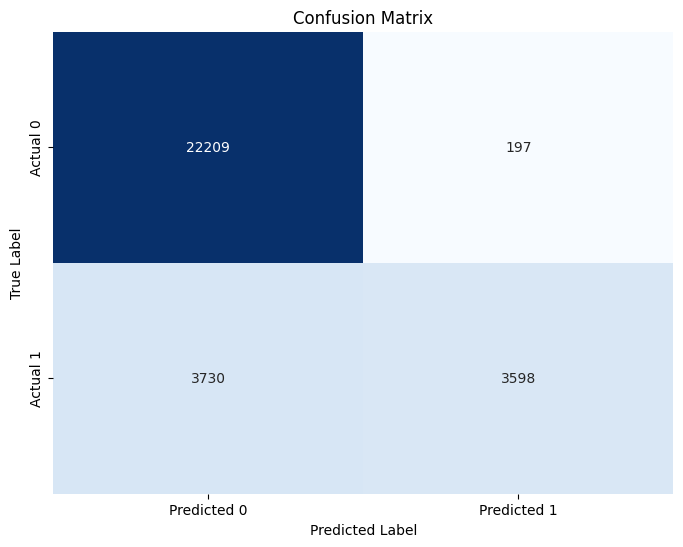

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**Reasoning**:
To evaluate the model's performance using an ROC curve and AUC score, I need to predict probabilities on the test set, calculate FPR, TPR, and AUC, and then plot the ROC curve.



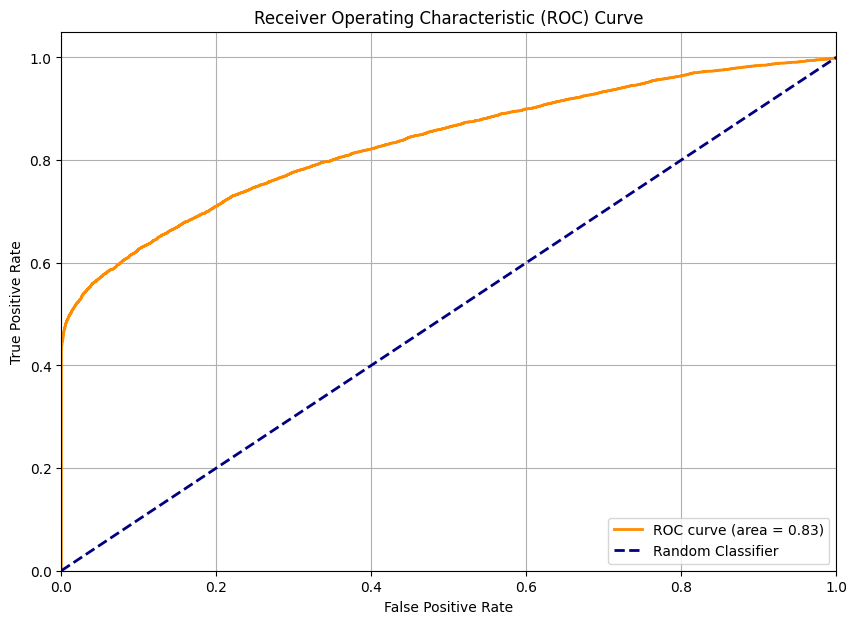

AUC Score: 0.83


In [22]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities for the positive class (class 1)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate FPR, TPR, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_pred_proba)

# Plot the ROC curve
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"AUC Score: {auc_score:.2f}")

**Reasoning**:
I need to create a Pandas DataFrame `y_pred_df` from the `y_pred_proba` array and name the column 'predicted_proba' as instructed. This will make the predicted probabilities accessible for further analysis.



In [23]:
y_pred_df = pd.DataFrame(y_pred_proba, columns=['predicted_proba'])
print("DataFrame y_pred_df created successfully.")
display(y_pred_df.head())

DataFrame y_pred_df created successfully.


,predicted_proba
0,0.052291
1,0.148289
2,0.167070
3,0.100096
4,0.175052


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Instantiate a RandomForestClassifier model
# Setting random_state for reproducibility
rf_model = RandomForestClassifier(random_state=42)

# 2. Train the RandomForestClassifier model
print("Training RandomForestClassifier model...")
rf_model.fit(X_train, y_train)
print("RandomForestClassifier model trained successfully!")

# 3. Make predictions on the X_test dataset
y_pred_rf = rf_model.predict(X_test)

# 4. Print a classification report
print("\nRandomForestClassifier - Classification Report:")
print(classification_report(y_test, y_pred_rf))

# 5. Print a confusion matrix
print("\nRandomForestClassifier - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Training RandomForestClassifier model...
RandomForestClassifier model trained successfully!

RandomForestClassifier - Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93     22406
           1       0.93      0.60      0.73      7328

    accuracy                           0.89     29734
   macro avg       0.91      0.79      0.83     29734
weighted avg       0.90      0.89      0.88     29734


RandomForestClassifier - Confusion Matrix:
[[22096   310]
 [ 2911  4417]]


In [28]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Instantiate SMOTE
smote = SMOTE(random_state=42)

# 2. Apply SMOTE to the training data
print("Original training set shape:", Counter(y_train))
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# 3. Print the value counts of y_resampled to verify class balance
print("Resampled training set shape:", Counter(y_resampled))

Original training set shape: Counter({0: 89625, 1: 29311})
Resampled training set shape: Counter({0: 89625, 1: 89625})


In [29]:
new_applicant_data = {
    'loan_limit': ['cf'],
    'Gender': ['Male'],
    'approv_in_adv': ['pre'],
    'loan_type': ['type1'],
    'loan_purpose': ['p1'],
    'Credit_Worthiness': ['l1'],
    'open_credit': ['nopc'],
    'business_or_commercial': ['nob/c'],
    'loan_amount': [300000],
    'term': [360.0],
    'Neg_ammortization': ['not_neg'],
    'interest_only': ['not_int'],
    'lump_sum_payment': ['not_lpsm'],
    'property_value': [450000.0],
    'occupancy_type': ['pr'],
    'income': [7500.0],
    'credit_type': ['CRIF'],
    'Credit_Score': [720],
    'co-applicant_credit_type': ['EXP'],
    'age': [38.0],
    'LTV': [66.67],
    'Region': ['North'],
    'Security_Type': ['direct'],
    'Status': [0],
    'dtir1': [30.0]
}

new_applicant_df = pd.DataFrame(new_applicant_data)
print("Hypothetical new applicant DataFrame created successfully.")
display(new_applicant_df)

Hypothetical new applicant DataFrame created successfully.


,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,term,...,income,credit_type,Credit_Score,co-applicant_credit_type,age,LTV,Region,Security_Type,Status,dtir1
0,cf,Male,pre,type1,p1,l1,nopc,nob/c,300000,360.0,...,7500.0,CRIF,720,EXP,38.0,66.67,North,direct,0,30.0
